In [81]:
import pandas as pd

# **PHASE 2: DATA CLEANING & PREPROCESSING**

# ***1.Handle Missing Values & Duplicates***

In [82]:
df = pd.read_csv("web_series_raw_1200.csv") #loading the scrapped file

In [83]:
df.head() #checking the dataset

,Title,Language,Genres,Rating,Premiered,Status
0,Under the Dome,English,"Drama, Science-Fiction, Thriller",6.6,2013-06-24,Ended
1,Person of Interest,English,"Action, Crime, Science-Fiction",8.8,2011-09-22,Ended
2,Bitten,English,"Drama, Horror, Romance",7.4,2014-01-11,Ended
3,Arrow,English,"Drama, Action, Science-Fiction",7.4,2012-10-10,Ended
4,True Detective,English,"Drama, Crime, Thriller",8.1,2014-01-12,Running


**Checking missing values**

In [84]:
# checking missing values
df.isnull().sum()
#problems exist in data
#Some web series have no rating
#one have have missing premiered date

Title          0
Language       0
Genres       123
Rating       153
Premiered      1
Status         0
dtype: int64

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      1208 non-null   object 
 1   Language   1208 non-null   object 
 2   Genres     1085 non-null   object 
 3   Rating     1055 non-null   float64
 4   Premiered  1207 non-null   object 
 5   Status     1208 non-null   object 
dtypes: float64(1), object(5)
memory usage: 56.8+ KB


# ***2.Fix inconsistent formats (date, text, numbers)***

In [86]:
df["Premiered"] = pd.to_datetime(df["Premiered"])#Converted to datetime:

**Removing Premiered missing as date-based analysis needs it**

In [87]:
df = df.dropna(subset=["Premiered"])

# ***3.Create useful features (rating %, price band, category, etc.)***

**Feature 1: Rating Percentage**

In [88]:
df["Rating_Percent"] = df["Rating"] * 10

**Feature 2: Release Year**

In [89]:
df["Release_Year"] = df["Premiered"].dt.year

**Feature 3: Age of the show**

In [90]:
df["Show_Age"] = 2026 - df["Release_Year"]

**Feature 4: Popularity Category (based on rating)**

In [91]:
def popularity(r):
    if r >= 8:
        return "High"
    elif r >= 6:
        return "Medium"
    else:
        return "Low"

df["Popularity"] = df["Rating"].apply(popularity)

**Feature 5: Main Genre**

In [92]:
df["Main_Genre"] = df["Genres"].apply(lambda x: x.split(",")[0] if pd.notnull(x) else None)

# ***4.Convert raw, messy data → structured analytics table***

In [93]:
df.head() #Now making changes in updated data after adding five new columns Structured Analytics Table

,Title,Language,Genres,Rating,Premiered,Status,Rating_Percent,Release_Year,Show_Age,Popularity,Main_Genre
0,Under the Dome,English,"Drama, Science-Fiction, Thriller",6.6,2013-06-24,Ended,66.0,2013,13,Medium,Drama
1,Person of Interest,English,"Action, Crime, Science-Fiction",8.8,2011-09-22,Ended,88.0,2011,15,High,Action
2,Bitten,English,"Drama, Horror, Romance",7.4,2014-01-11,Ended,74.0,2014,12,Medium,Drama
3,Arrow,English,"Drama, Action, Science-Fiction",7.4,2012-10-10,Ended,74.0,2012,14,Medium,Drama
4,True Detective,English,"Drama, Crime, Thriller",8.1,2014-01-12,Running,81.0,2014,12,High,Drama


In [94]:
df.isnull().sum() #checking nulls

Title               0
Language            0
Genres            122
Rating            152
Premiered           0
Status              0
Rating_Percent    152
Release_Year        0
Show_Age            0
Popularity          0
Main_Genre        122
dtype: int64

**Replacing missing Rating and Rating_Percent with median rating**

In [95]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Rating_Percent"] = df["Rating"] * 10

**Replacing missing genres with "Unknown" keyword**

In [96]:
df["Genres"] = df["Genres"].fillna("Unknown")
df["Main_Genre"] = df["Main_Genre"].fillna("Unknown")

In [97]:
df.isnull().sum() #noww no null values

Title             0
Language          0
Genres            0
Rating            0
Premiered         0
Status            0
Rating_Percent    0
Release_Year      0
Show_Age          0
Popularity        0
Main_Genre        0
dtype: int64

In [98]:
df.duplicated().sum() # no duplicate columns

0

**20 duplicates shows with same tittle**

In [99]:
df.duplicated(subset=["Title"]).sum()
#20 duplicate shows (same title)

20

In [100]:
df[df.duplicated(subset=["Title"], keep=False)].sort_values("Title") #checking the duplicate shows

,Title,Language,Genres,Rating,Premiered,Status,Rating_Percent,Release_Year,Show_Age,Popularity,Main_Genre
158,Battlestar Galactica,English,"Drama, Science-Fiction, War",8.7,2003-12-08,Ended,87.0,2003,23,High,Drama
1027,Battlestar Galactica,English,"Action, Adventure, Science-Fiction",7.9,1978-09-17,Ended,79.0,1978,48,Medium,Action
784,Being Human,English,"Drama, Comedy, Science-Fiction",8.1,2009-01-25,Ended,81.0,2009,17,High,Drama
209,Being Human,English,"Drama, Horror, Romance",7.5,2011-01-17,Ended,75.0,2011,15,Medium,Drama
459,Charlie's Angels,English,"Action, Adventure",7.7,1976-09-22,Ended,77.0,1976,50,Medium,Action
432,Charlie's Angels,English,"Action, Crime",7.7,2011-09-22,Ended,77.0,2011,15,Medium,Action
1051,Coupling,English,"Comedy, Romance",8.0,2000-05-12,Ended,80.0,2000,26,High,Comedy
1052,Coupling,English,"Drama, Comedy, Romance",6.0,2003-09-25,Ended,60.0,2003,23,Medium,Drama
1057,Cupid,English,"Drama, Romance",7.1,2009-03-31,Ended,71.0,2009,17,Medium,Drama
1056,Cupid,English,"Drama, Comedy, Romance",8.0,1998-09-26,Ended,80.0,1998,28,High,Drama


In [101]:
df = df.drop_duplicates(subset=["Title"], keep="first") # droping the same title shows

In [102]:
df.duplicated(subset=["Title"]).sum() # no duplicate titles now 

0

**Final Structured Analytics Table**

In [103]:
df.to_csv("web_series_cleaned_data.csv", index=False) #saving the clean data this file will be used in Power Bi for making Dashboard

In [104]:
df_check = pd.read_csv("web_series_cleaned_data.csv") #Checking the Final Structured data 
df_check.head()

,Title,Language,Genres,Rating,Premiered,Status,Rating_Percent,Release_Year,Show_Age,Popularity,Main_Genre
0,Under the Dome,English,"Drama, Science-Fiction, Thriller",6.6,2013-06-24,Ended,66.0,2013,13,Medium,Drama
1,Person of Interest,English,"Action, Crime, Science-Fiction",8.8,2011-09-22,Ended,88.0,2011,15,High,Action
2,Bitten,English,"Drama, Horror, Romance",7.4,2014-01-11,Ended,74.0,2014,12,Medium,Drama
3,Arrow,English,"Drama, Action, Science-Fiction",7.4,2012-10-10,Ended,74.0,2012,14,Medium,Drama
4,True Detective,English,"Drama, Crime, Thriller",8.1,2014-01-12,Running,81.0,2014,12,High,Drama


# **PHASE 3 : EXPLORATORY DATA ANALYSIS (EDA)**

# ***1.Summary statistics (mean, median, spread)***

In [105]:
df.describe()

,Rating,Premiered,Rating_Percent,Release_Year,Show_Age
count,1187.000000,1187,1187.000000,1187.000000,1187.000000
mean,7.432098,2007-06-26 10:08:59.848357120,74.320977,2006.962089,19.037911
min,3.000000,1955-09-10 00:00:00,30.000000,1955.000000,11.000000
25%,7.200000,2005-01-06 00:00:00,72.000000,2005.000000,13.000000
50%,7.600000,2010-08-03 00:00:00,76.000000,2010.000000,16.000000
75%,7.900000,2013-05-30 12:00:00,79.000000,2013.000000,21.000000
max,9.200000,2015-06-30 00:00:00,92.000000,2015.000000,71.000000
std,0.773958,NaN,7.739580,8.854420,8.854420


# ***2.Trend analysis (time, category, rating, price, etc.)***

**A) Rating trend over time**

In [106]:
rating_by_year = df.groupby("Release_Year")["Rating"].mean()
rating_by_year

Release_Year
1955    7.800000
1957    6.400000
1959    8.900000
1964    7.400000
1965    7.000000
1966    8.000000
1967    8.000000
1968    7.550000
1969    7.600000
1970    7.600000
1972    8.500000
1974    7.400000
1975    7.200000
1976    7.950000
1977    7.100000
1979    6.400000
1980    8.100000
1981    7.800000
1982    7.775000
1983    7.366667
1984    7.433333
1985    7.700000
1986    7.333333
1987    7.300000
1988    6.900000
1989    7.588889
1990    7.675000
1991    7.200000
1992    7.383333
1993    7.646667
1994    7.318182
1995    7.760000
1996    7.184615
1997    7.908333
1998    7.558333
1999    7.766667
2000    7.694737
2001    7.576190
2002    7.280000
2003    7.455556
2004    7.302778
2005    7.558696
2006    7.473913
2007    7.528333
2008    7.450000
2009    7.413115
2010    7.515789
2011    7.365094
2012    7.403030
2013    7.336885
2014    7.328042
2015    7.391892
Name: Rating, dtype: float64

**B) Genre-wise rating trend**

In [107]:
df.groupby("Main_Genre")["Rating"].mean().sort_values(ascending=False)

Main_Genre
Anime              8.275000
Mystery            7.825000
Medical            7.700000
Science-Fiction    7.666667
Travel             7.650000
Fantasy            7.633333
Nature             7.633333
War                7.600000
Action             7.585714
Drama              7.579933
Horror             7.480000
History            7.385714
Thriller           7.333333
Crime              7.330000
Comedy             7.321236
Adventure          7.158333
Food               7.138095
DIY                7.100000
Unknown            7.089167
Sports             7.050000
Children           6.860000
Family             6.700000
Music              6.512500
Supernatural       6.400000
Romance            6.028571
Name: Rating, dtype: float64

**C) Popularity distribution**

In [108]:
df["Popularity"].value_counts()

Popularity
Medium    731
High      253
Low       203
Name: count, dtype: int64

# ***3.Visualizations***

**A) Bar chart – Average rating by genre**

<Axes: xlabel='Main_Genre'>

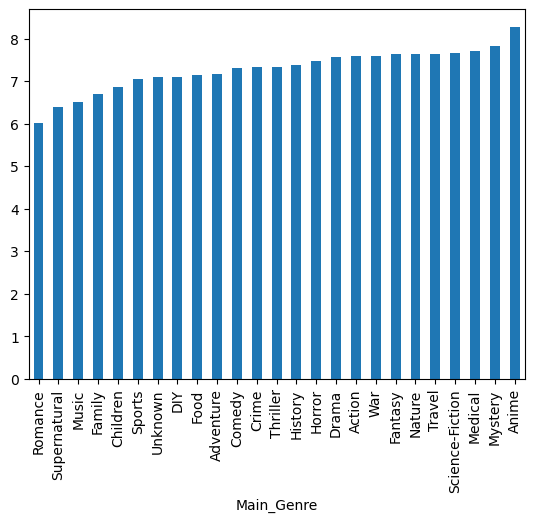

In [109]:
df.groupby("Main_Genre")["Rating"].mean().sort_values().plot(kind="bar")

**B) Line chart – Rating trend over years**

<Axes: xlabel='Release_Year'>

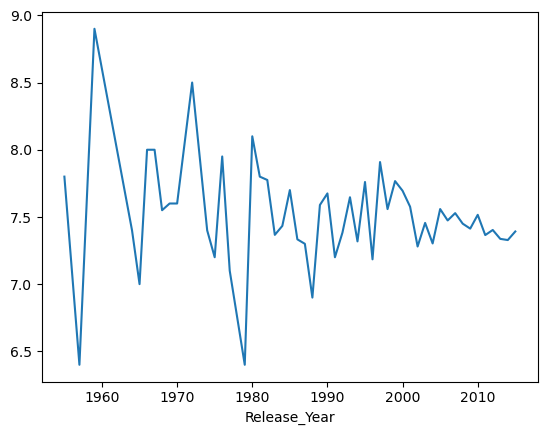

In [110]:
rating_by_year.plot(kind="line")

**C) Scatter plot – Show age vs rating**

<Axes: xlabel='Show_Age', ylabel='Rating'>

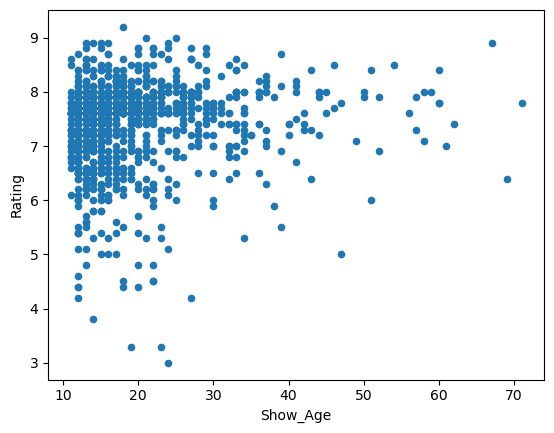

In [111]:
df.plot(kind="scatter", x="Show_Age", y="Rating")

**d) Boxplot (Outliers)**

<Axes: >

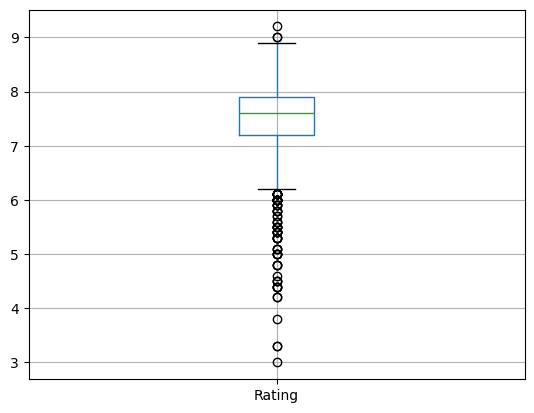

In [112]:
df.boxplot(column="Rating")

**e) Heatmap (Correlation Analysis)**

In [113]:
numeric_df = df[["Rating", "Rating_Percent", "Show_Age", "Release_Year"]]
numeric_df.corr()

,Rating,Rating_Percent,Show_Age,Release_Year
Rating,1.000000,1.000000,0.082184,-0.082184
Rating_Percent,1.000000,1.000000,0.082184,-0.082184
Show_Age,0.082184,0.082184,1.000000,-1.000000
Release_Year,-0.082184,-0.082184,-1.000000,1.000000


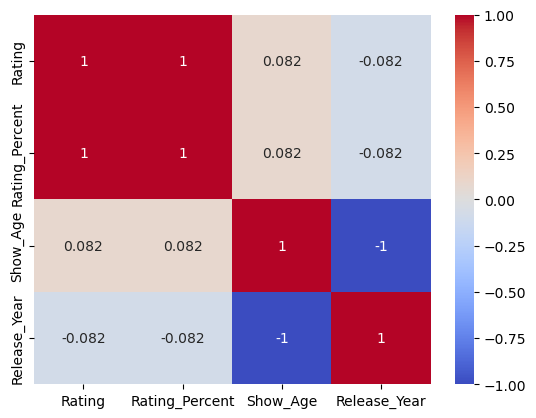

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

**4.Identify trends, patterns & anomalies**

*High-rating years*<br>
*•1959 (8.9)*<br>
*•1972 (8.5)*<br>
*Low Rating Years*<br>
*•1957 (6.4)*<br>
*•1979 (6.4)*<br>

*Top-rated genres from output*<br>
*•Anime (~8.27)*<br>
*•Mystery (~7.82)*<br>
*•Medical / Science-Fiction / Travel / Fantasy / Nature / War (7.7-7.6 range)*

*Lower-rated genres<br>*
*•Romance*<br>
*•Music*<br>
*•Supernatural*<br>
*•Family / Children*

*“Genre-wise analysis reveals that Anime and Mystery series<br>
receive the highest average ratings, while Romance and Music<br>
genres show comparatively lower audience ratings.”*

*-------------------------------------------------------------------------------------------------------*

*Popularity Distribution*<br>
*Distribution*<br>
*•Medium → 731*<br>
*•High → 253*<br>
*•Low → 203*

*Majority of web series fall into the medium popularity category*<br>
*with fewer extremely high- or low-rated shows.*<br>
*This indicates:*<br>
*that extreme ratings are relatively rare and the majority of content performs moderately well.*

*-------------------------------------------------------------------------------------------------------*

*What the plot shows:<br>
No strong upward or downward trend<br>
Older shows can have both high and low ratings<br>
Newer shows cluster around 7–8 rating range*

*Show age does not strongly influence rating
Quality matters more than how old the show is.*

*-------------------------------------------------------------------------------------------------------*

*Box PlotObservations<br>
Most ratings lie between 7.0 and 8.0<br>
Few shows below 4.0 → very poorly rated<br>
Few shows above 9.0 → critically acclaimed*

*Boxplot analysis identifies a small number of outliers with extremely low and high ratings,<br>
representing unusually poor or exceptionally successful web series.*

*-------------------------------------------------------------------------------------------------------*

*Key correlations<br>
Rating & Rating_Percent → Perfect correlation (1.0) (expected)<br>
Show_Age & Release_Year → -1 correlation <br>
Rating vs Show_Age → Very weak correlation (~0.08)*

*Correlation analysis shows that ratings have very weak correlation with show age and release year,<br>
indicating that temporal factors have minimal impact on audience ratings.*

*-------------------------------------------------------------------------------------------------------*

*Exploratory Data Analysis revealed that web series ratings over time,<br>
with Anime and Mystery genres achieving the highest average ratings. Most series fall into <br>
the medium popularity category. Scatter and correlation analysis indicate that show age has<br>
minimal influence on ratings, while boxplots highlight a small number of exceptionally high- <br>
and low-rated shows.*